In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

%cd /home/smalani/PartialObservations

cwd = os.getcwd()
print(cwd)

/home/smalani/PartialObservations
/home/smalani/PartialObservations


8.822957897791639e-05
(10000,)


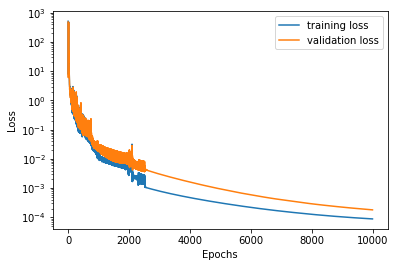

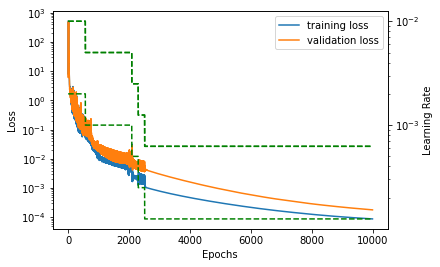

In [2]:
train_loss = np.load('data/model__training_loss.npy')
val_loss = np.load('data/model__validation_loss.npy')
epoch_list = np.load('data/model__lr_epoch.npy')
lr_list = np.load('data/model__lr_track.npy', allow_pickle=True)

print(train_loss[-5])
print(train_loss.shape)

plt.figure()
plt.semilogy(range(train_loss.shape[0]),train_loss,label='training loss')
plt.semilogy(range(train_loss.shape[0]),val_loss,label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('Figures/trainingloss.png')

fig, ax2 = plt.subplots()
ax2.semilogy(range(train_loss.shape[0]),train_loss,label='training loss')
ax2.semilogy(range(train_loss.shape[0]),val_loss,label='validation loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
plt.legend()
ax = ax2.twinx()
ax.semilogy(epoch_list,lr_list,'g--')
ax.set_xlabel('Epochs')
ax.set_ylabel('Learning Rate')

plt.savefig('Figures/trainingloss_learningrate.png')

In [3]:
from config import config
from main.utils import Network, MLP
import torch

f = np.load("minmax/minmax.npz")

xmax = f['arr_0']
xmin = f['arr_1']
print(xmax)
print(xmin)

norm_func = lambda input, device: (input - torch.tensor(xmin).float().to(device)) / \
                        ((torch.tensor((xmax - xmin)).float().to(device)) + 1e-10)
inv_norm_func = lambda input, device: input * ((torch.tensor((xmax - xmin)).float().to(device)) + 1e-10) \
                                + torch.tensor(xmin).float().to(device)

# Create the network architecture

if config["MODEL"]["BOX"] == 'Black':
    # Create the network architecture
    mlp = MLP(5, config["MODEL"]["NUM_HIDDEN"], 6)
    
    class my_Network(Network):
        def __init__(self, network, train_size, xdim, norm_func=lambda input, device: input,
                        inv_norm_func=lambda input, device: input, init_available=True, device=None, 
                        tf_prop=1., integrator='RK4', add_par_num=0):
            super(my_Network, self).__init__(network, train_size, xdim, norm_func,
                        inv_norm_func, init_available, device, 
                        tf_prop, integrator, add_par_num)

            self.additional_pars = torch.nn.Parameter((torch.zeros(6)-1).to(self.device), requires_grad = True) 

        def output(self, x, par):

            # ANN_input = torch.cat((self.norm_func(x), par/20), dim=-1)
            ANN_input = self.norm_func(x)[...,[0,2,3,4,5]]
            out = self.net(ANN_input) #* (2 ** (self.additional_pars))
            # print(out)
            out = self.inv_norm_func(out) * (2 ** (7 * self.additional_pars))
            zeros = torch.zeros((out[...,[0]].shape)).to(self.device)
            out = torch.cat((out[...,[0]],zeros,out[...,2:]), -1)
            # print(out)
            # assert False
            # out = out * torch.tensor([1000, 5e-168, 2.7, 1000, 17000, 6.2]).to(self.device)
            return out

elif config["MODEL"]["BOX"] == 'Grey' or config["MODEL"]["BOX"] == 'Gray':
    
    # Create the network architecture
    mlp = MLP(6, config["MODEL"]["NUM_HIDDEN"], 3)
    
    if config["MODEL"]["Parameters"] == 'Trainable':
        class my_Network(Network):
            def __init__(self, network, train_size, xdim, norm_func=lambda input, device: input,
                            inv_norm_func=lambda input, device: input, init_available=True, device=None, 
                            tf_prop=1., integrator='RK4', add_par_num=2):
                super(my_Network, self).__init__(network, train_size, xdim, norm_func,
                            inv_norm_func, init_available, device, 
                            tf_prop, integrator, add_par_num)

                self.additional_pars = torch.nn.Parameter((torch.cat(((torch.tensor([0.4476, -0.4859, -0.6419])), 
                                                                        (torch.zeros(4) + 1)))).to(self.device), 
                                                            requires_grad = True)

            def output(self, x_input, par):
                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input)
                ANN_output = ANN_output * (100 ** (self.additional_pars[:3]))

                x, y, z, u, v, g = torch.unbind(x_input, dim=-1)

                u1_prime_x, u2_prime_y, u3_prime_z = torch.unbind(ANN_output, dim=-1)                

                omega = self.additional_pars[-4] * 10
                sigma = self.additional_pars[-3] * 10
                rho = self.additional_pars[-2] / 10
                eta = self.additional_pars[-1]

                alpha, uf, _, _, _, _, _, _, uc1_prime, uc2_prime, uc3_prime = datagen.par_fun()

                output = []

                output.append(-alpha * x + u1_prime_x - uc1_prime * x)
                output.append(-alpha * y + u2_prime_y - uc2_prime * y)
                output.append(-alpha * z + u3_prime_z - uc3_prime * z)
                output.append(alpha * (uf - u) - u1_prime_x)
                output.append(-alpha * v + omega * u1_prime_x - u2_prime_y - sigma * u3_prime_z)
                output.append(-alpha * g + rho * u2_prime_y + eta * u3_prime_z)

                out = torch.stack((output), dim=-1)
                return out
            def raw_output(self, x_input, par):

                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input) * (100 ** (self.additional_pars[:3]))

                return ANN_output
    elif config["MODEL"]["Parameters"] == 'Fixed':
        class my_Network(Network):
            def __init__(self, network, train_size, xdim, norm_func=lambda input, device: input,
                            inv_norm_func=lambda input, device: input, init_available=True, device=None, 
                            tf_prop=1., integrator='RK4', add_par_num=2):
                super(my_Network, self).__init__(network, train_size, xdim, norm_func,
                            inv_norm_func, init_available, device, 
                            tf_prop, integrator, add_par_num)

                # self.additional_pars = torch.nn.Parameter((torch.zeros(2)-0.5).to(self.device), 
                #                             requires_grad = True)
                self.additional_pars = torch.nn.Parameter((torch.tensor([0.4476, -0.4859, -0.6419])).to(self.device), 
                                                                requires_grad = True)

                

            def output(self, x_input, par):
                
                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input)
                ANN_output = ANN_output * (100 ** (self.additional_pars))

                x, y, z, u, v, g = torch.unbind(x_input, dim=-1)
                u1_prime_x, u2_prime_y, u3_prime_z = torch.unbind(ANN_output, dim=-1)

                alpha, uf, omega, sigma, rho, eta, phi1, phi2, uc1_prime, uc2_prime, uc3_prime = datagen.par_fun(D=1/7.3, sf=2.5)

                output = []

                # output.append(-alpha * x + u1_prime * x - uc1_prime * x)
                # output.append(torch.zeros(output[-1].shape).to(self.device))
                # output.append(-alpha * z + u3_prime * z - uc3_prime * z)
                # output.append(alpha * (uf - u) - u1_prime * x)
                # output.append(-alpha * v + omega * u1_prime * x - u2_prime * y - sigma * u3_prime * z)
                # output.append(-alpha * g + rho * u2_prime * y + eta * u3_prime * z)

                output.append(-alpha * x + u1_prime_x - uc1_prime * x)

                output.append(-alpha * y + u2_prime_y - uc2_prime * y)
                # output.append(torch.zeros(output[-1].shape).to(self.device))

                output.append(-alpha * z + u3_prime_z - uc3_prime * z)
                output.append(alpha * (uf - u) - u1_prime_x)
                output.append(-alpha * v + omega * u1_prime_x - u2_prime_y - sigma * u3_prime_z)
                output.append(-alpha * g + rho * u2_prime_y + eta * u3_prime_z)

                out = torch.stack((output), dim=-1)
                return out
            def raw_output(self, x_input, par):

                ANN_input = self.norm_func(x_input)
                ANN_output = self.net(ANN_input) * (100 ** (self.additional_pars))

                return ANN_output

    else:
        raise ValueError("Tell me whether to train the parameters!")
else:
    raise ValueError("Tell me what box to use!")


network = my_Network(mlp, config["DATA"]["N_TRAIN"], 6, norm_func=norm_func, inv_norm_func=inv_norm_func, 
                      init_available=config["DATA"]["INIT_AVAILABLE"], integrator='RK4')
device = 'cpu'

filename = 'data/' + 'model_' + '.net'

print(filename)


state_dict = torch.load(filename, map_location=torch.device(device))
network.load_state_dict(state_dict, strict=False)

print(network)
network.double()

[7.76480999e+01 6.13450077e-02 3.52889567e-01 2.08507400e+02
 2.11354658e+03 8.21362308e-01]
[1.45181035e+01 1.12344629e-04 2.81247634e-01 3.24970859e+01
 3.97881635e+02 6.58996734e-01]
data/model_.net
my_Network(
  (net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=32, bias=True)
      (1): Linear(in_features=32, out_features=32, bias=True)
    )
    (activation): SiLU()
    (output_layer): Linear(in_features=32, out_features=3, bias=True)
  )
)


my_Network(
  (net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=32, bias=True)
      (1): Linear(in_features=32, out_features=32, bias=True)
    )
    (activation): SiLU()
    (output_layer): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [4]:
from BandFModel import datagen
from main import preprocess

data_train = datagen.generate_data(n_train=config["DATA"]["N_TRAIN"],
                                   tmax=config["DATA"]["TMAX"]*10,
                                   x_sample_num=(config["DATA"]["X_SAMPLE_NUM"]-1)*10+1,
                                   detail=True,
                                   theta_random=False)
# dataset_train = preprocess.Dataset(*data_train)

  0%|          | 0/200 [00:00<?, ?it/s]

pakapaaakaaa detail
(200, 6)


In [5]:
from BandFModel.datagen import par_fun, ode_fun

alpha, uf, omega, sigma, rho, eta, phi1, phi2, uc1_prime, uc2_prime, uc3_prime = par_fun(sf=2.5, D=1/7.3)
alpha = data_train[4].reshape((-1,))

x = data_train[3][...,0].reshape((-1,))
y = data_train[3][...,1].reshape((-1,))
z = data_train[3][...,2].reshape((-1,))
u = data_train[3][...,3].reshape((-1,))
v = data_train[3][...,4].reshape((-1,))
g = data_train[3][...,5].reshape((-1,))
var = (x,y,z,u,v,g)

pars = par_fun(sf=2.5, D=1/alpha)
print(pars[0].shape)

output = ode_fun(0., var, pars)
print(output.shape)
print(x.shape)

(200000,)
(200000, 6)
(200000,)


In [6]:
x_in = torch.tensor(data_train[3]).to(network.device)
p_in = torch.tensor(data_train[4]).unsqueeze(-1).to(network.device)

if config["MODEL"]["BOX"] == 'Grey':
    phi_output = network.raw_output(x_in.reshape((-1,6)), p_in.reshape((-1,1))).cpu().detach().numpy()
    print(phi_output.shape)

(200000, 3)


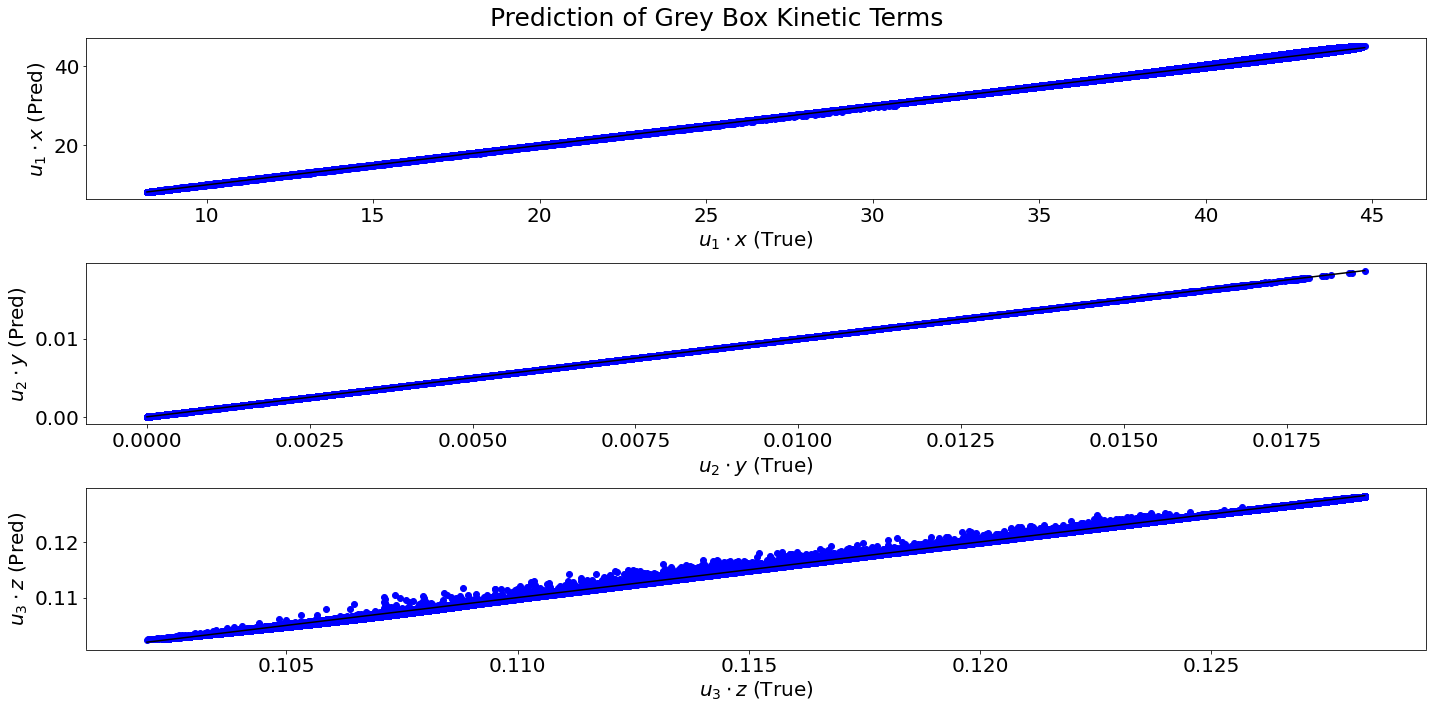

9.7
10.0
0.1313868613138686
1.2916666666666667


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of ticklabels (8).

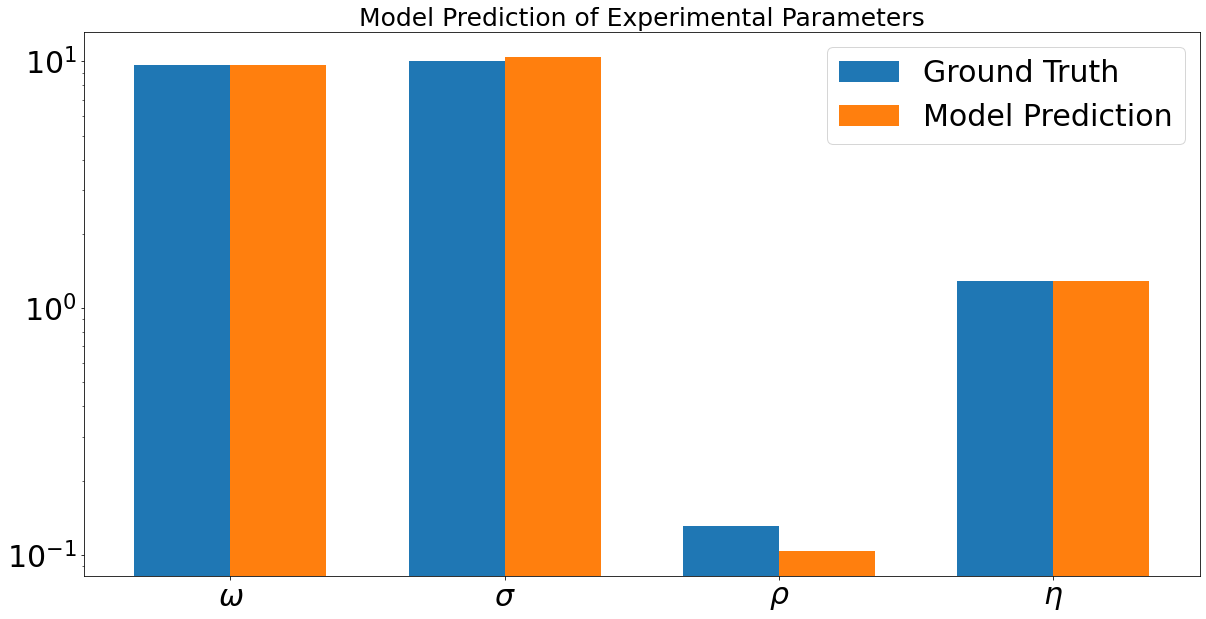

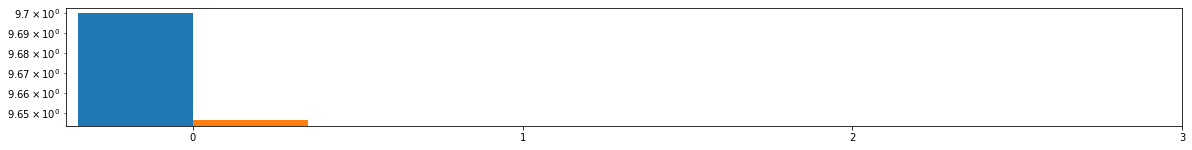

In [7]:
 if config["MODEL"]["BOX"] == 'Grey':
        alpha, uf, omega, sigma, rho, eta, phi1, phi2, uc1_prime, uc2_prime, uc3_prime = pars

        u1_prime = x * u / ((1+u) * (1+g))
        u2_prime = y * phi1 * v / (1+v)
        u3_prime = z * phi2 * v / (sigma + v)

        plt.figure(figsize=(20,10))


        ax = plt.subplot(311)
        ax.plot([np.min(u1_prime), np.max(u1_prime)],[np.min(u1_prime), np.max(u1_prime)], 'k-')
        ax.scatter(u1_prime,phi_output[:,0],color='blue')
        ax.set_ylabel(r'$u_1\cdot x$ (Pred)', fontsize=20)
        ax.tick_params(axis='y', labelsize=20)  
        ax.set_xlabel(r'$u_1\cdot x$ (True)', fontsize=20)
        ax.tick_params(axis='x', labelsize=20)  


        ax = plt.subplot(312)
        ax.plot([np.min(u2_prime), np.max(u2_prime)],[np.min(u2_prime), np.max(u2_prime)], 'k-')
        ax.scatter(u2_prime,phi_output[:,1],color='blue')
        ax.set_ylabel(r'$u_2\cdot y$ (Pred)', fontsize=20)
        ax.tick_params(axis='y', labelsize=20)  
        ax.set_xlabel(r'$u_2\cdot y$ (True)', fontsize=20)
        ax.tick_params(axis='x', labelsize=20)  

        ax = plt.subplot(313)
        ax.plot([np.min(u3_prime), np.max(u3_prime)],[np.min(u3_prime), np.max(u3_prime)], 'k-')
        ax.scatter(u3_prime,phi_output[:,2],color='blue')
        ax.set_ylabel(r'$u_3\cdot z$ (Pred)', fontsize=20)
        ax.tick_params(axis='y', labelsize=20)  
        ax.set_xlabel(r'$u_3\cdot z$ (True)', fontsize=20)
        ax.tick_params(axis='x', labelsize=20)  
        
        plt.suptitle('Prediction of Grey Box Kinetic Terms', fontsize=25)
        plt.tight_layout()
        plt.savefig('Figures/Prediction_of_phi.png')
        plt.show()

        if config["MODEL"]["Parameters"] == 'Trainable':

                labels = [r'$\omega$',r'$\sigma$',r'$\rho$',r'$\eta$']
                x_axis = np.arange(len(labels))
                width = 0.35

                print(omega)
                print(network.additional_pars[-4] * 10)
                print('----------------------')
                print(sigma)
                print(network.additional_pars[-3] * 10)
                print('----------------------')
                print(rho)
                print(network.additional_pars[-2] / 10)
                print('----------------------')
                print(eta)
                print(network.additional_pars[-1])
                print('----------------------')

                fig = plt.figure(figsize=(20,10))
                ax = fig.add_subplot(111)
                ax.bar(x_axis-width/2,[omega, sigma, rho, eta],width=width,label='Ground Truth')
                ax.bar(x_axis+width/2,[network.additional_pars[-4] * 10, 
                                network.additional_pars[-3] * 10,
                                network.additional_pars[-2] / 10,
                                network.additional_pars[-1] ],
                        width=width,label='Model Prediction')
                ax.set_xticks(x_axis)
                ax.set_yscale('log')
                ax.set_xticklabels(labels,fontsize=30)
                plt.yticks(fontsize=30)
                plt.title('Model Prediction of Experimental Parameters',fontsize=25)
                plt.legend(fontsize=30)

                fig = plt.figure(figsize=(20,10))
                ax = fig.add_subplot(411)
                ax.bar(-width/2,[omega],width=width,label='Ground Truth')
                ax.bar(width/2,[network.additional_pars[-4] * 10],
                        width=width,label='Model Prediction')
                ax.set_xticks(x_axis)
                ax.set_yscale('log')
                ax.set_xticklabels(r'$\omega$',fontsize=30)
                plt.yticks(fontsize=30)
                plt.title('Model Prediction of Experimental Parameters',fontsize=25)
                plt.legend(fontsize=30)

                plt.savefig('Figures/Prediction_of_Parameters.png')

In [8]:
from BandFModel.datagen import par_fun, ode_fun

t_start = 0

alpha, uf, omega, sigma, rho, eta, phi1, phi2, uc1_prime, uc2_prime, uc3_prime = par_fun(sf=2.5, D=1/7.3)
alpha = data_train[4][:,t_start:].reshape((-1,))


x = data_train[3][:,t_start:,0].reshape((-1,))
y = data_train[3][:,t_start:,1].reshape((-1,))
z = data_train[3][:,t_start:,2].reshape((-1,))
u = data_train[3][:,t_start:,3].reshape((-1,))
v = data_train[3][:,t_start:,4].reshape((-1,))
g = data_train[3][:,t_start:,5].reshape((-1,))

time = data_train[2][:,t_start:].reshape((-1,))
var = (x,y,z,u,v,g)
pars = par_fun(sf=2.5, D=1/alpha)
output = ode_fun(0., var, pars)

x_in = torch.tensor(data_train[3][:,t_start:,:]).to(network.device)
p_in = torch.tensor(data_train[4][:,t_start:]).unsqueeze(-1).to(network.device)

ANN_output = network.output(x_in.reshape((-1,6)), p_in.reshape((-1,1))).cpu().detach().numpy()

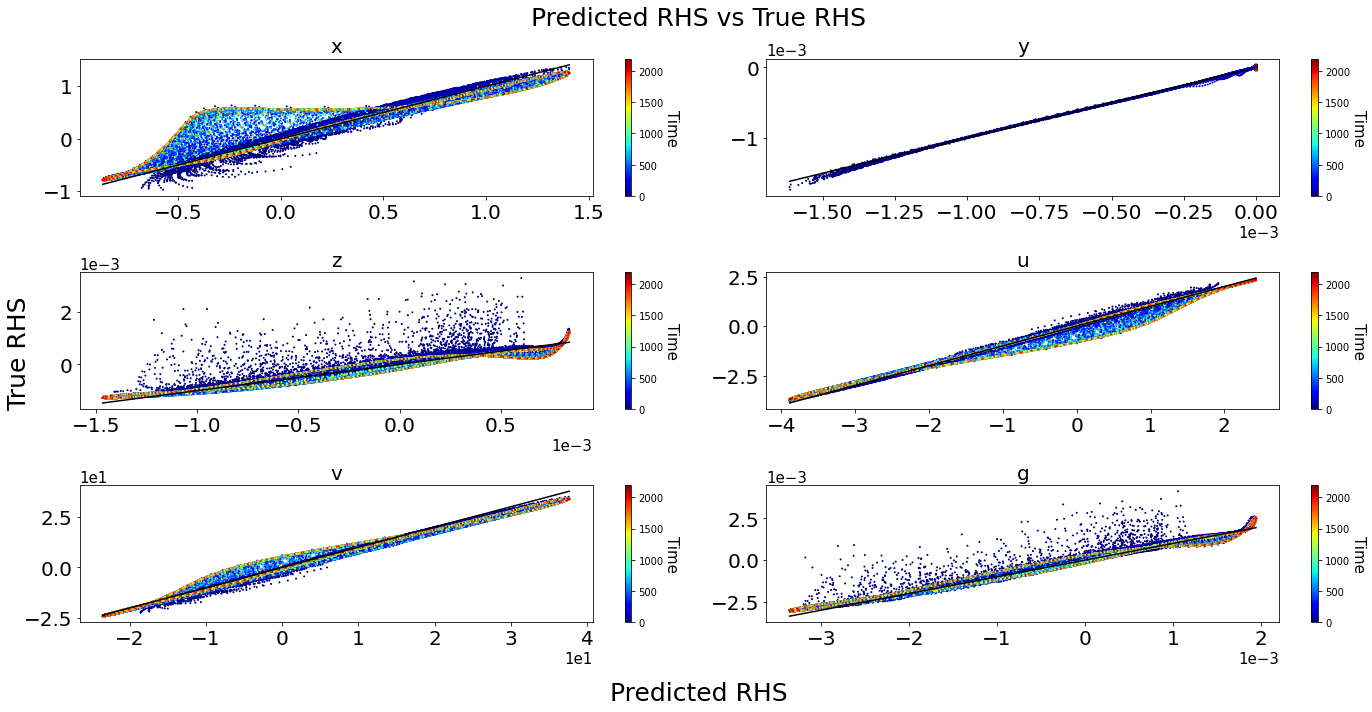

In [9]:
fig = plt.figure(figsize=(20,10))

labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(32) + str(i+1)))
    axplot = ax.scatter(output[:,i], ANN_output[:,i], c=time, cmap='jet', s=1)
    ax.plot([np.min(output[:,i]), np.max(output[:,i])],[np.min(output[:,i]), np.max(output[:,i])], 'k-')
    # ax.set_ylabel('RHS of ' + labels[i] + ' (Pred)', fontsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
    ax.yaxis.offsetText.set_fontsize(15)
    # ax.set_xlabel('RHS of ' + labels[i] + ' (True)', fontsize=20)
    ax.tick_params(axis='x', labelsize=20) 
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
    ax.xaxis.offsetText.set_fontsize(15)
    plt.title(labels[i], fontsize=20)
    cbar = fig.colorbar(axplot, ax=ax)
    cbar.set_label('Time', rotation=270, fontsize=15, labelpad=15)

plt.suptitle('Predicted RHS vs True RHS', fontsize=25)
# fig.text(0.5, 0.04, 'True RHS', ha='center', fontsize=25)
# fig.text(0.04, 0.5, 'Predicted RHS', va='center', rotation='vertical', fontsize=25)

fig.supxlabel('Predicted RHS', fontsize=25)
fig.supylabel('True RHS', fontsize=25)
plt.tight_layout()
plt.savefig('Figures/Prediction_of_RHS.png')
plt.show()


In [10]:
from torch.utils.data import DataLoader

data_train_traj = datagen.generate_data(n_train=2, 
                                   tmax=config["DATA"]["TMAX"],
                                   x_sample_num=config["DATA"]["X_SAMPLE_NUM"],
                                   detail=True,
                                   theta_random=False,
                                   init_available=True)
data_train = datagen.generate_data(n_train=3, 
                                   tmax=config["DATA"]["TMAX"]*10,
                                   x_sample_num=(config["DATA"]["X_SAMPLE_NUM"]-1)*10+1,
                                   detail=True,
                                   theta_random=False,
                                   init_available=True)
dataset_train = preprocess.Dataset(*data_train[:2])

t_in = torch.tensor(data_train_traj[2]).to(network.device)
x_in = torch.tensor(data_train_traj[3]).to(network.device)
p_in = torch.tensor(data_train_traj[4]).unsqueeze(-1).to(network.device)

  0%|          | 0/2 [00:00<?, ?it/s]

pakapaaakaaa detail
(2, 6)


  0%|          | 0/3 [00:00<?, ?it/s]

pakapaaakaaa detail
(3, 6)


In [11]:
from scipy.integrate import solve_ivp

import numpy as np

index = 2

def ode_NN_func(t,x,p):
    x_in = torch.tensor(x).reshape((-1,6)).to(network.device)
    p_in = torch.tensor(p).reshape((-1,1)).to(network.device)
    return network.output(x_in, p_in).cpu().detach().numpy()

sol_pred = solve_ivp(ode_NN_func, y0=dataset_train.x[index,0,:], 
                t_span=[dataset_train.full_times_arr[index][0],dataset_train.full_times_arr[index][-1]], 
                args=(dataset_train.p[[index],[0],[0]],), 
                rtol=1e-10, atol=1e-10)

a,b,c,d,e,f = dataset_train.x[index,0,:]

sol_true = solve_ivp(ode_fun, y0=dataset_train.x[index,0,:], 
                t_span=[dataset_train.full_times_arr[index][0],dataset_train.full_times_arr[index][-1]], 
                args=(par_fun(D=1/dataset_train.p[[index],[0],[0]], sf=2.5),), 
                rtol=1e-10, atol=1e-10)

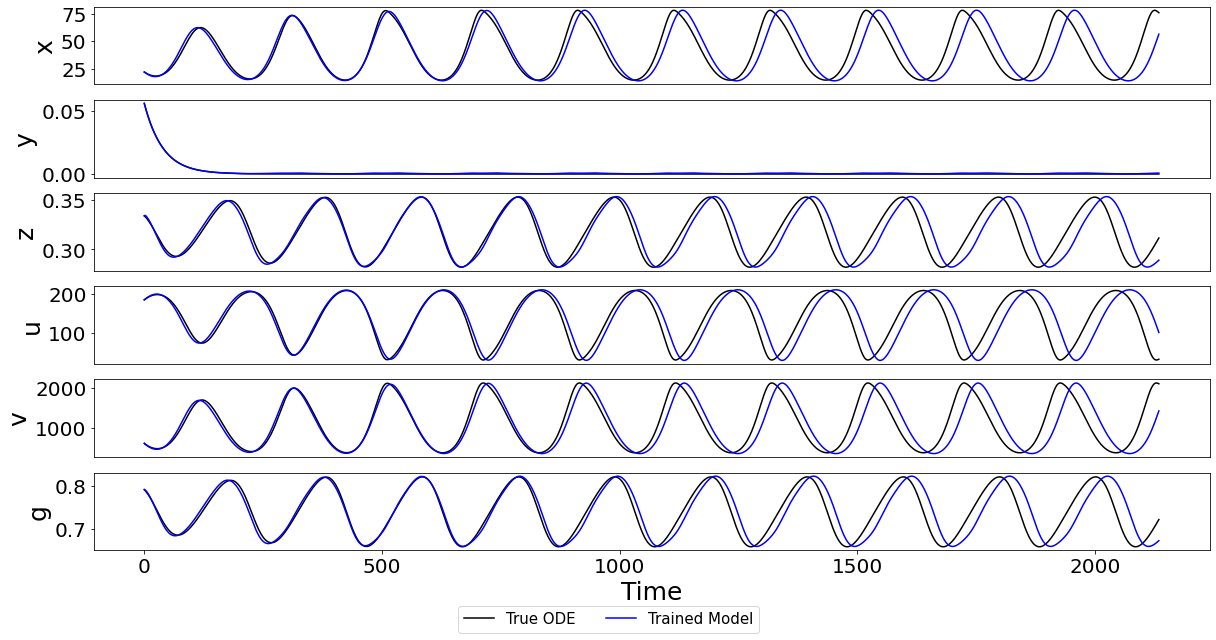

In [12]:
# plt.figure(figsize=(20,10))
# labels = ['x', 'y', 'z', 'u', 'v', 'g']
# for i in range(6):
#     ax = plt.subplot(int(str(61) + str(i+1)))
#     ax.plot(sol_true.t, sol_true.y[i,:], 'k')
#     ax.set_ylabel(labels[i], color='k')
#     ax.plot(sol_pred.t, sol_pred.y[i,:], 'b')
#     # ax.set_ylabel(labels[i] + ' pred', color='k')
# plt.xlabel('Time')
# plt.savefig('Figures/Prediction_Trajectory.png')
# plt.show()

fig = plt.figure(figsize=(20,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(61) + str(i+1)))
    ax.plot(sol_true.t, sol_true.y[i,:], 'k', label='True ODE')
    ax.plot(sol_pred.t, sol_pred.y[i,:], 'b', label='Trained Model')
    ax.set_ylabel(labels[i], color='k', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)                              
    if i<5:
        ax.set_xticks([])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=15)

plt.xlabel('Time', fontsize=25)
ax.tick_params(axis='x', labelsize=20)
plt.savefig('Figures/Prediction_Trajectory.png')
plt.show()

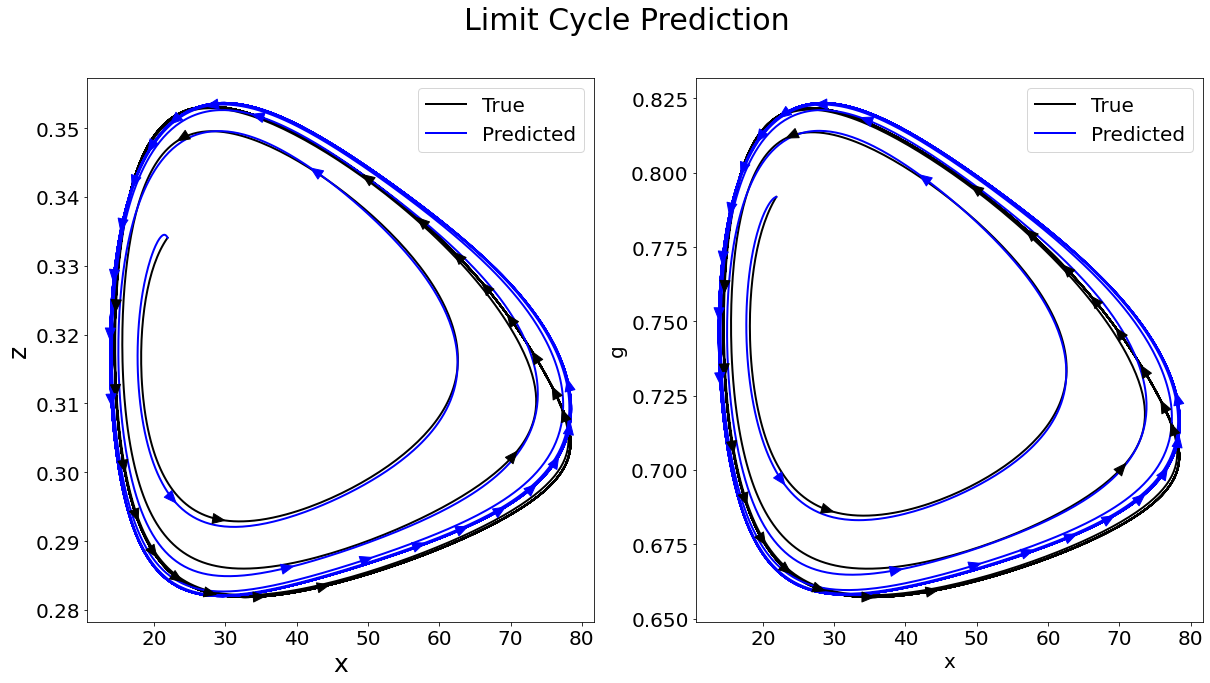

In [13]:
plt.figure(figsize=(20,10))

arrow_freq = 20
true_freq = int(np.floor(sol_true.y[0,:].size/arrow_freq))
pred_freq = int(np.floor(sol_pred.y[0,:].size/arrow_freq))

ax = plt.subplot(121)
ax.plot(sol_true.y[0,:], sol_true.y[2,:], 'k', linewidth=2, label='True')
ax.plot(sol_pred.y[0,:], sol_pred.y[2,:], 'b', linewidth=2, label='Predicted')
for i in range(arrow_freq):
    ax.annotate("", xy=(sol_true.y[0,int((i+0.5)*true_freq)+1], sol_true.y[2,int((i+0.5)*true_freq)+1]), 
                    xytext=(sol_true.y[0,int((i+0.5)*true_freq)], sol_true.y[2,int((i+0.5)*true_freq)]),
            arrowprops=dict(headwidth=10, color='k'))
    ax.annotate("", xy=(sol_pred.y[0,int((i+0.5)*pred_freq)+1], sol_pred.y[2,int((i+0.5)*pred_freq)+1]), 
                    xytext=(sol_pred.y[0,int((i+0.5)*pred_freq)], sol_pred.y[2,int((i+0.5)*pred_freq)]),
            arrowprops=dict(headwidth=10, color='b'))
ax.legend(fontsize=20)
ax.set_ylabel('z', color='k', fontsize=25)
ax.tick_params(axis='y', labelsize=20)
ax.set_xlabel('x', color='k', fontsize=25)
ax.tick_params(axis='x', labelsize=20)


ax = plt.subplot(122)
ax.plot(sol_true.y[0,:], sol_true.y[5,:], 'k', linewidth=2, label='True')
ax.plot(sol_pred.y[0,:], sol_pred.y[5,:], 'b', linewidth=2, label='Predicted')
for i in range(arrow_freq):
    ax.annotate("", xy=(sol_true.y[0,int((i+0.5)*true_freq)+1], sol_true.y[5,int((i+0.5)*true_freq)+1]), 
                    xytext=(sol_true.y[0,int((i+0.5)*true_freq)], sol_true.y[5,int((i+0.5)*true_freq)]),
            arrowprops=dict(headwidth=10, color='k'))
    ax.annotate("", xy=(sol_pred.y[0,int((i+0.5)*pred_freq)+1], sol_pred.y[5,int((i+0.5)*pred_freq)+1]), 
                    xytext=(sol_pred.y[0,int((i+0.5)*pred_freq)], sol_pred.y[5,int((i+0.5)*pred_freq)]),
            arrowprops=dict(headwidth=10, color='b'))
ax.legend(fontsize=20)
ax.set_ylabel('g', color='k', fontsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_xlabel('x', color='k', fontsize=20)
ax.tick_params(axis='x', labelsize=20)

plt.suptitle('Limit Cycle Prediction', fontsize=30)
plt.savefig('Figures/Prediction_Phase_Plot.png')
plt.show()

In [14]:
data_train_load = np.load("data/training_data.npy", allow_pickle=True)
data_train_par_load = np.load("data/training_data_par.npy", allow_pickle=True)
data_train_detail_t_load = np.load("data/training_data_detail_t.npy", allow_pickle=True)
data_train_detail_x_load = np.load("data/training_data_detail_x.npy", allow_pickle=True)
data_train_detail_par_load = np.load("data/training_data_detail_par.npy", allow_pickle=True)

dataset_train_load = preprocess.Dataset(data_train_load,data_train_par_load)

In [15]:
index = 5    
tspan = [dataset_train_load.full_times_arr[index][0],
         dataset_train_load.full_times_arr[index][-1]]

def ode_NN_func(t,x,p):
    x_in = torch.tensor(x).reshape((-1,6)).to(network.device)
    p_in = torch.tensor(p).reshape((-1,1)).to(network.device)
    return network.output(x_in, p_in).cpu().detach().numpy()

sol_pred = solve_ivp(ode_NN_func, y0=data_train_detail_x_load[index,0,:], 
                t_span=tspan, 
                args=(dataset_train_load.p[[index],[0],[0]],), 
                rtol=1e-10, atol=1e-10)

initial = inv_norm_func(network.initial_x[index,:], device=network.device).detach().cpu().numpy()
sol_pred_init = solve_ivp(ode_NN_func, y0=initial, 
                t_span=tspan, 
                args=(dataset_train_load.p[[index],[0],[0]],), 
                rtol=1e-10, atol=1e-10)

a,b,c,d,e,f = dataset_train_load.x[index,0,:]
sol_true = solve_ivp(ode_fun, y0=data_train_detail_x_load[index,0,:], 
                t_span=tspan, 
                args=(par_fun(D=1/dataset_train_load.p[[index],[0],[0]], sf=2.5),), 
                rtol=1e-10, atol=1e-10)
sol_true_initial = solve_ivp(ode_fun, y0=initial, 
                t_span=tspan, 
                args=(par_fun(D=1/dataset_train_load.p[[index],[0],[0]], sf=2.5),), 
                rtol=1e-10, atol=1e-10)

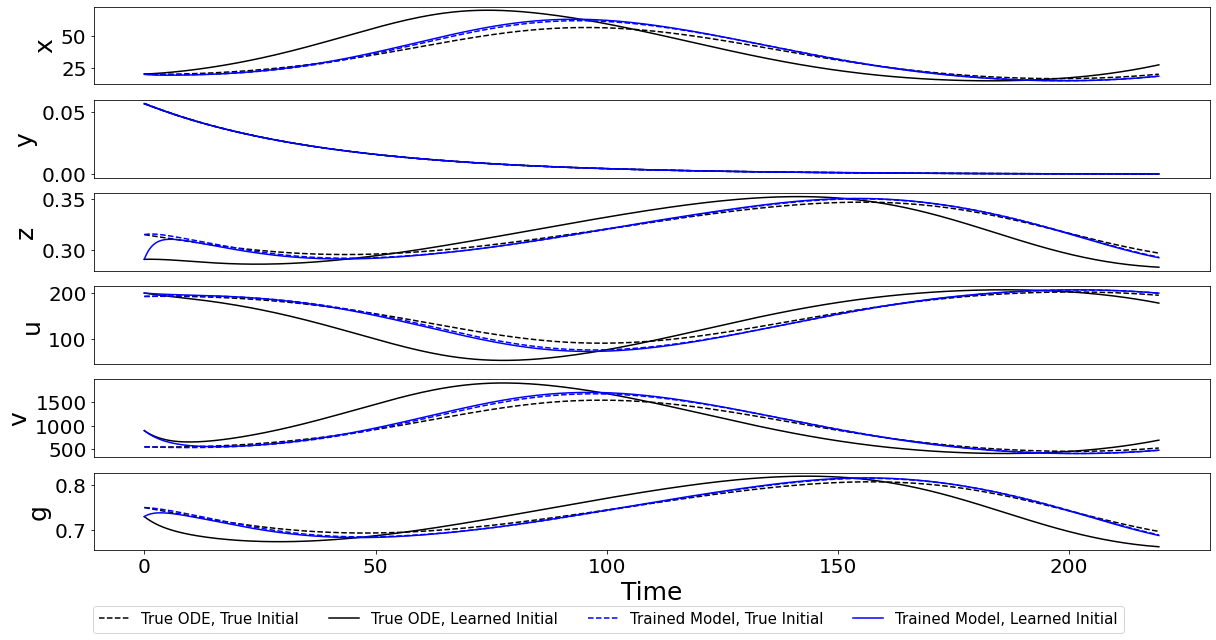

In [16]:
fig = plt.figure(figsize=(20,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(61) + str(i+1)))
    ax.plot(sol_true.t, sol_true.y[i,:], 'k--', label='True ODE, True Initial')
    ax.plot(sol_true_initial.t, sol_true_initial.y[i,:], 'k', label='True ODE, Learned Initial')
    ax.set_ylabel(labels[i], color='k', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)                              
    if i<5:
        ax.set_xticks([])

    ax.plot(sol_pred.t, sol_pred.y[i,:], 'b--', label='Trained Model, True Initial')
    ax.plot(sol_pred_init.t, sol_pred_init.y[i,:], 'b', label='Trained Model, Learned Initial')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=15)

plt.xlabel('Time', fontsize=25)
ax.tick_params(axis='x', labelsize=20)
plt.savefig('Figures/Initial_Condition_Integration_Trajectory_ShortTime.png')
plt.show()

In [17]:
index = 5    
tspan = [dataset_train_load.full_times_arr[index][0],
         dataset_train_load.full_times_arr[index][-1]*10]

def ode_NN_func(t,x,p):
    x_in = torch.tensor(x).reshape((-1,6)).to(network.device)
    p_in = torch.tensor(p).reshape((-1,1)).to(network.device)
    return network.output(x_in, p_in).cpu().detach().numpy()

sol_pred = solve_ivp(ode_NN_func, y0=data_train_detail_x_load[index,0,:], 
                t_span=tspan, 
                args=(dataset_train_load.p[[index],[0],[0]],), 
                rtol=1e-10, atol=1e-10)

initial = inv_norm_func(network.initial_x[index,:], device=network.device).detach().cpu().numpy()
sol_pred_init = solve_ivp(ode_NN_func, y0=initial, 
                t_span=tspan, 
                args=(dataset_train_load.p[[index],[0],[0]],), 
                rtol=1e-10, atol=1e-10)

a,b,c,d,e,f = dataset_train_load.x[index,0,:]
sol_true = solve_ivp(ode_fun, y0=data_train_detail_x_load[index,0,:], 
                t_span=tspan, 
                args=(par_fun(D=1/dataset_train_load.p[[index],[0],[0]], sf=2.5),), 
                rtol=1e-10, atol=1e-10)
sol_true_initial = solve_ivp(ode_fun, y0=initial, 
                t_span=tspan, 
                args=(par_fun(D=1/dataset_train_load.p[[index],[0],[0]], sf=2.5),), 
                rtol=1e-10, atol=1e-10)

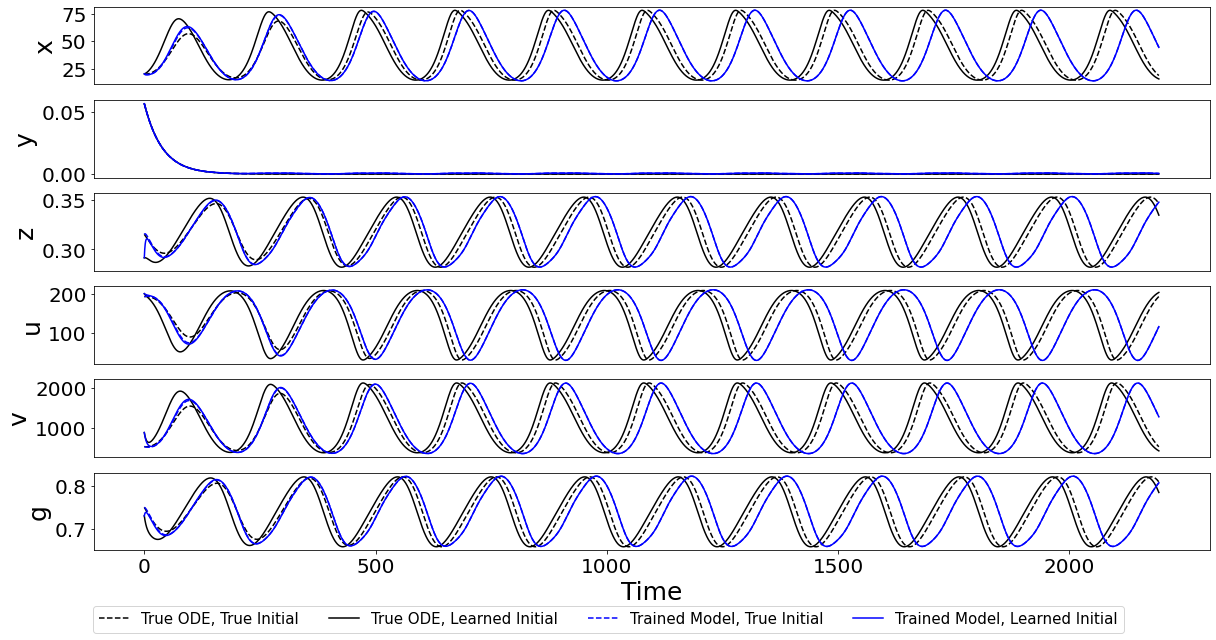

In [18]:
fig = plt.figure(figsize=(20,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    ax = plt.subplot(int(str(61) + str(i+1)))
    ax.plot(sol_true.t, sol_true.y[i,:], 'k--', label='True ODE, True Initial')
    ax.plot(sol_true_initial.t, sol_true_initial.y[i,:], 'k', label='True ODE, Learned Initial')
    ax.set_ylabel(labels[i], color='k', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)
    if i<5:
        ax.set_xticks([])

    ax.plot(sol_pred.t, sol_pred.y[i,:], 'b--', label='Trained Model, True Initial')
    ax.plot(sol_pred_init.t, sol_pred_init.y[i,:], 'b', label='Trained Model, Learned Initial')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=15)

plt.xlabel('Time', fontsize=25)
ax.tick_params(axis='x', labelsize=20)
plt.savefig('Figures/Initial_Condition_Integration_Trajectory_LongTime.png')
plt.show()

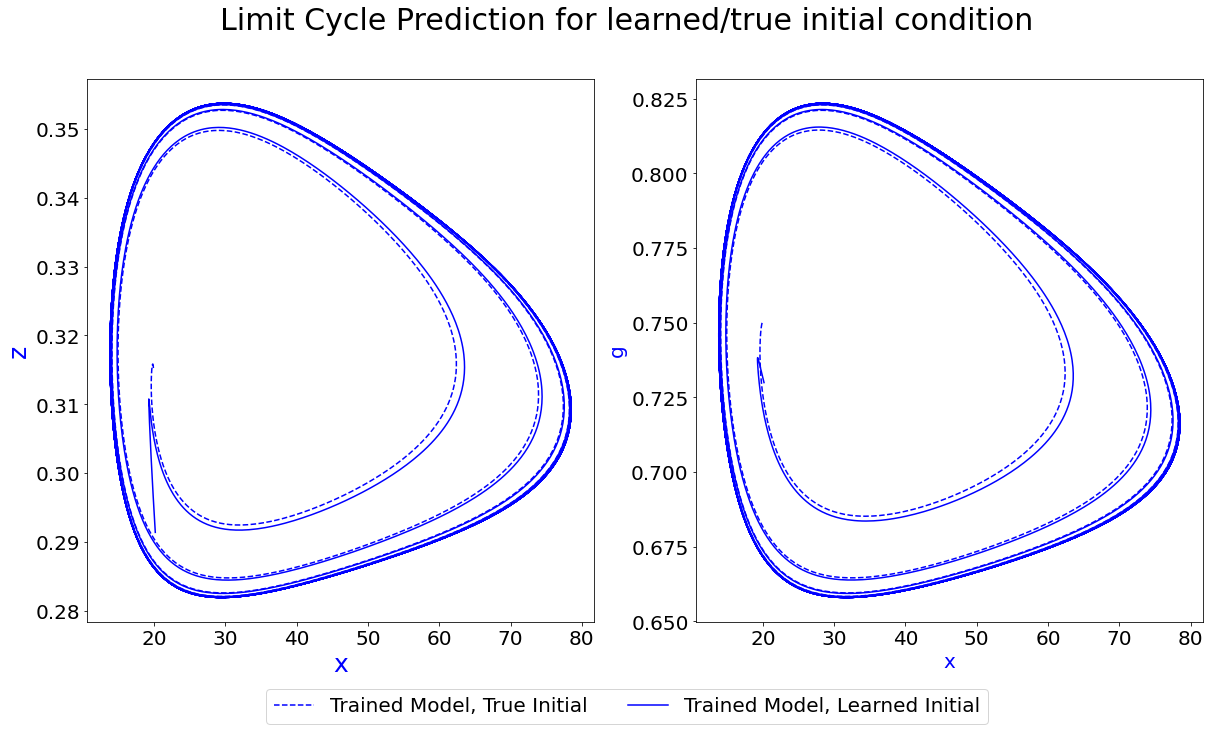

In [19]:
fig = plt.figure(figsize=(20,10))

arrow_freq = 20
true_freq = int(np.floor(sol_true.y[0,:].size/arrow_freq))
pred_freq = int(np.floor(sol_pred.y[0,:].size/arrow_freq))

ax = plt.subplot(121)
ax.plot(sol_pred.y[0,:], sol_pred.y[2,:], 'b--', label='Trained Model, True Initial')
ax.plot(sol_pred_init.y[0,:], sol_pred_init.y[2,:], 'b', label='Trained Model, Learned Initial')
ax.set_ylabel('z', color='b', fontsize=25)
ax.tick_params(axis='y', labelsize=20)
ax.set_xlabel('x', color='b', fontsize=25)
ax.tick_params(axis='x', labelsize=20)

# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, loc='center', ncol=4, fontsize=15)

ax = plt.subplot(122)
ax.plot(sol_pred.y[0,:], sol_pred.y[5,:], 'b--', label='Trained Model, True Initial')
ax.plot(sol_pred_init.y[0,:], sol_pred_init.y[5,:], 'b', label='Trained Model, Learned Initial')
ax.set_ylabel('g', color='b', fontsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_xlabel('x', color='b', fontsize=20)
ax.tick_params(axis='x', labelsize=20)

plt.suptitle('Limit Cycle Prediction for learned/true initial condition', fontsize=30)

handles, labels = ax.get_legend_handles_labels()
leg = fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=20, bbox_to_anchor= (0.5, -0.03))

plt.savefig('Figures/Initial_Condition_Phase_Plot.png')
plt.show()